# Import Library

In [54]:
# Data Manipulation & System Utilities
import kagglehub # Access Kaggle resource anywhere
import numpy as np # Linear algebra and array manipulation
import pandas as pd # Data processing and CSV file I/O
import os # Operating system interface (file path management)
import time # Provides various time-related functions
from google.colab import files

# Machine Learning Preprocessing
from sklearn.model_selection import train_test_split # Splitting data into Train/Test/Val sets
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Real-time data augmentation
from tensorflow.keras.preprocessing import image

# Image Processing & Visualization
import cv2 # OpenCV for advanced image processing
import matplotlib.pyplot as plt # Basic plotting and visualization
from mpl_toolkits.axes_grid1 import ImageGrid # Creating sophisticated layouts for image grids
from numpy.random import shuffle # An inbuilt method of the random module
import seaborn as sns

# Model Architecture (Transfer Learning)
import keras # Multi-backend deep learning framework
from tensorflow.keras.applications import InceptionV3 # Pre-trained CNN architecture
from tensorflow.keras.models import Model # Functional API to build the model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization # Building blocks
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout

# Model Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Training Optimizers
from tensorflow.keras.optimizers import Adam, Adamax # Modern gradient descent algorithms

# Load Dataset

In [ ]:
# Automatically download and set the directory path for the kidney CT-Scan dataset from Kaggle.
path = kagglehub.dataset_download("fatemehmehrparvar/lung-disease")
print("Path to dataset files:", path)
parent_dir = os.path.join(path, "Lung X-Ray Image", "Lung X-Ray Image")

# Determine the path for each type of case
lung_opacity_path = os.path.join(parent_dir, "Lung_Opacity")
normal_path = os.path.join(parent_dir, "Normal")
viral_pneumonia_path = os.path.join(parent_dir, "Viral Pneumonia")

# Print path to verify
print("Lung Opacity Directory:", lung_opacity_path)
print("Normal Directory:", normal_path)
print("Pneumonia Directory:", viral_pneumonia_path)

100%|██████████| 34.9M/34.9M [00:01<00:00, 22.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1
Lung Opacity Directory: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Lung_Opacity
Normal Directory: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Normal
Pneumonia Directory: /root/.cache/kagglehub/datasets/fatemehmehrparvar/lung-disease/versions/1/Lung X-Ray Image/Lung X-Ray Image/Viral Pneumonia


# Exploratory Data Analysis (EDA)

In [ ]:
# Counting the number of files in each folder
num_lung_opacity = len(os.listdir(lung_opacity_path))
num_normal = len(os.listdir(normal_path))
num_viral_pneumonia = len(os.listdir(viral_pneumonia_path))

# Print path to verify
print("Number of Lung Opacity Case Data :", num_lung_opacity)
print("Number of Normal Case Data :", num_normal)
print("Number of Viral Pneumonia Data :", num_viral_pneumonia)

# Calculating the overall total
total_data = num_lung_opacity + num_normal + num_viral_pneumonia
print("Total Seluruh Data :", total_data)

Number of Lung Opacity Case Data : 1125
Number of Normal Case Data : 1250
Number of Viral Pneumonia Data : 1100
Total Seluruh Data : 3475


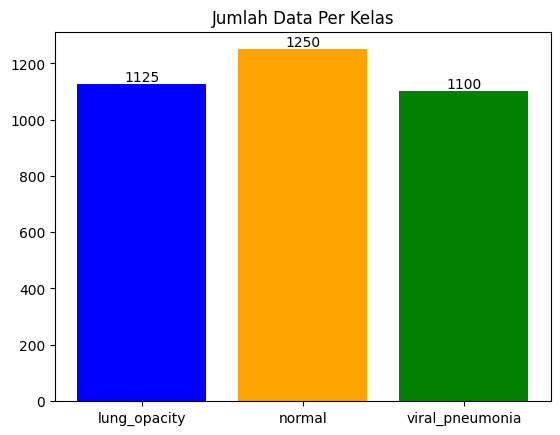

In [ ]:
# Data Folders
data_folders = {
  "lung_opacity": num_lung_opacity,
  "normal": num_normal,
  "viral_pneumonia": num_viral_pneumonia,
}

# Count the number of files and at the same time get the category names
labels = list(data_folders.keys())
counts = list(data_folders.values())

# show the graph
plt.bar(labels, counts, color=['blue', 'orange', 'green', 'red'])
plt.title("Jumlah Data Per Kelas")

# Add numbers above each bar for clarity
for i, v in enumerate(counts):
  plt.text(i, v+10, str(v), ha='center')

plt.show()

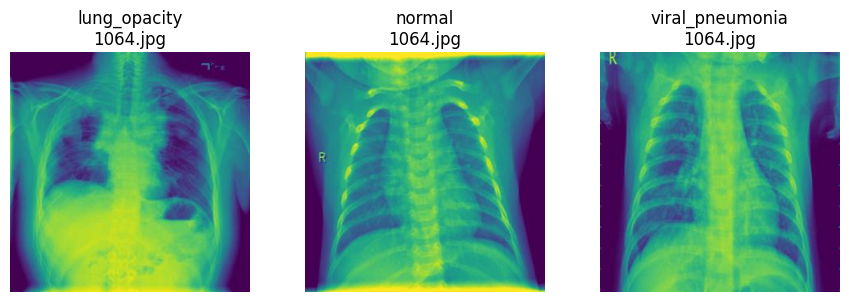

In [ ]:
# List of paths and labels according to the variables in your notebook
class_paths = {
  "lung_opacity": lung_opacity_path,
  "normal": normal_path,
  "viral_pneumonia": viral_pneumonia_path
}

# Preparing the plot
plt.figure(figsize=(9, 3))

for i, (label, path) in enumerate(class_paths.items()):
  # Taking a list of files and selecting the first file
  img_name = os.listdir(path)[0]
  img_path = os.path.join(path, img_name)

  # Reading images using OpenCV
  img = cv2.imread(img_path)
  # Conversion from BGR to RGB (Because OpenCV reads in BGR format)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  # Display image
  plt.subplot(1, 3, i + 1)
  plt.imshow(img)
  plt.title(f"{label}\n{img_name}")
  plt.axis('off')

plt.tight_layout()
plt.show()

# Data Preparation

In [ ]:
file_p = [] # Empty list to store the address (path) of each image file
labels = [] # Empty list to store labels/categories
# List of source folders
dict_lists = [normal_path, lung_opacity_path, viral_pneumonia_path]
# Appropriate category name
class_labels = ['Normal', 'Lung Opacity', 'Viral Pneumonia']

for i, path_to_process in enumerate(dict_lists):
  # Retrieving a list of all file names in a folder
  list_f = os.listdir(path_to_process)
  for name in list_f :
    # Combining folder name + file name
    fpath = os.path.join(path_to_process, name)
    # Enter the full address into the file_p list
    file_p.append(fpath)
    # Enter the appropriate label into the labels list
    labels.append(class_labels[i])

# Convert the list into the "filepaths" column
file_path = pd.Series(file_p, name="filepaths")
# Converting a list into the 'labels' column
labels_name = pd.Series(labels, name="labels")
# Combining the two columns side by side
data = pd.concat([file_path, labels_name], axis=1)
# Make it into a table structure (DataFrame)
df = pd.DataFrame(data)

df

,filepaths,labels
0,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
1,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
2,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
3,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
4,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Normal
...,...,...
3470,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3471,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3472,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia
3473,/root/.cache/kagglehub/datasets/fatemehmehrpar...,Viral Pneumonia


# Split Dataset

In [ ]:
# Division: 70% Train, 30% Remaining (for Val + Test)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Division of the Remaining (30%) into two: 15% Val and 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# This parameter ensures that the class proportions are the same as in the original data.

# A model is used to learn to recognize image patterns.
print(f"Training Images: {len(train_df)} Images")
# Digunakan untuk mengevaluasi model selama proses training (untuk tuning hyperparameter).
print(f"Validation Images: {len(val_df)} Images")
# Used only once at the end to see the model's original performance on data that is completely unfamiliar to it.
print(f"Testing Images: {len(test_df)} Images")

total_images = len(train_df) + len(val_df) + len(test_df)
print(f"Total Images: {total_images} Images")

Training Images: 2432 Images
Validation Images: 521 Images
Testing Images: 522 Images
Total Images: 3475 Images


# Preprocessing & Image Enhancement

In [ ]:
# Improving the visual quality of images through three main stages: Contrast, Sharpness (Sharpening), and Brightness.
def enhance_image(image):
  # Adjusting image contrast with linear blending technique
  image = cv2.addWeighted(image, 1.5, image, -0.5, 0)
  # Creating a 3x3 matrix (kernel) for a Sharpening filter
  kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
  # Applying the kernel to the image using the convolution function
  image = cv2.filter2D(image, -1, kernel)
  # Splitting an image into three separate color channels
  hue = image[:, :, 0]
  saturation = image[:, :, 1]
  value = image[:, :, 2]
  # Increase the brightness (value) by 25%
  value = np.clip(value * 1.25, 0, 255)
  # Reinserting the enhanced brightness channel back into the original image structure
  image[:, :, 2] = value

  # Returning the processed image (more contrasty, sharp, and bright) to be used in the next stage.
  return image

# Data Generator

Found 2432 validated image filenames belonging to 3 classes.
Found 521 validated image filenames belonging to 3 classes.
Found 522 validated image filenames belonging to 3 classes.



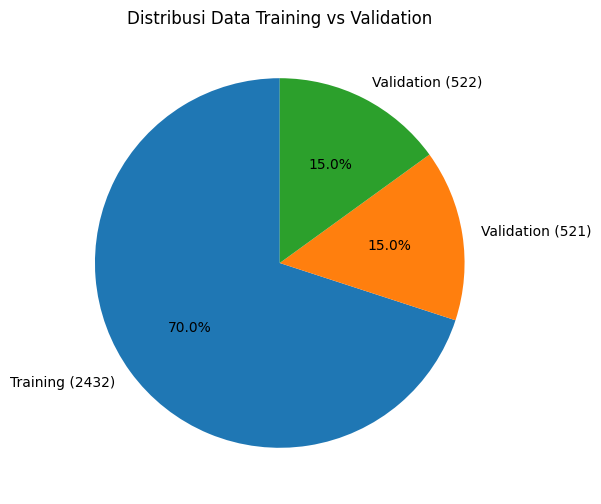

In [ ]:
batch_size=32

# Inisialisasi ImageDataGenerator
image_gen = ImageDataGenerator(
  # Semua nilai diubah menjadi rentang 0 hingga 1
  rescale = 1./255,
  # Menyuntikkan fungsi kustom enhance_image
  preprocessing_function = lambda image: enhance_image(image),
  )

# Data Latih
train_generator = image_gen.flow_from_dataframe(
  dataframe=train_df, # Sumber datanya
  x_col="filepaths", # Kolom di tabel yang menyimpan alamat/lokasi file gambar
  y_col="labels", # Kolom di tabel yang menyimpan kategori
  target_size=(256, 256), # Semua gambar "dipaksa" menjadi ukuran 256x256 pixel
  color_mode='rgb', # Gambar diproses dalam 3 saluran warna
  class_mode="categorical", # Karena melakukan klasifikasi 3 jenis penyakit
  batch_size=batch_size, # Gambar dikirim ke model 32 buah sekaligus dalam satu waktu
  shuffle=False) # Agar Urutan prediksi tidak tertukar dengan urutan label aslinya

# Data Validasi
val_generator = image_gen.flow_from_dataframe(
  dataframe=val_df,
  x_col="filepaths",
  y_col="labels",
  target_size=(256, 256),
  color_mode='rgb',
  class_mode="categorical",
  batch_size=batch_size,
  shuffle=False)

# Data Uji
test_generator = image_gen.flow_from_dataframe(
  dataframe=test_df,
  x_col="filepaths",
  y_col="labels",
  target_size=(256, 256),
  color_mode='rgb',
  class_mode="categorical",
  batch_size=batch_size,
  shuffle=False)

# Get the number of data from the generator
counts = [train_generator.samples, val_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Validation ({counts[2]})']
print("")

# Circle plot diagram (Pie Chart)
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Data Training vs Validation")
plt.show()

# Visualisasi Data Generator

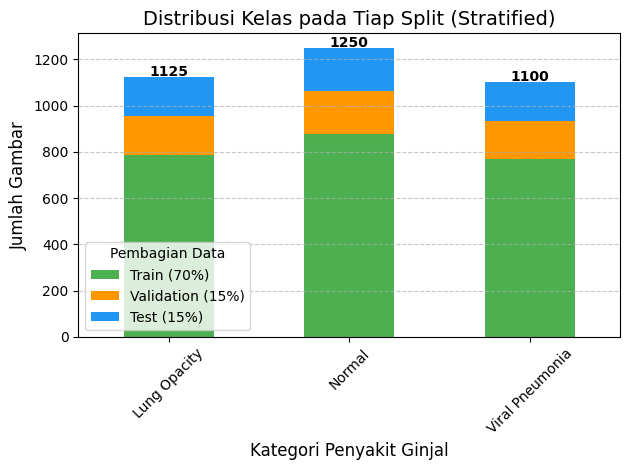

In [ ]:
# Count the number of data per class in each split
train_counts = train_df['labels'].value_counts().sort_index()
val_counts = val_df['labels'].value_counts().sort_index()
test_counts = test_df['labels'].value_counts().sort_index()

# Prepare Data for Plotting
categories = train_counts.index
df_plot = pd.DataFrame({ # Corrected 'Dataframe' to 'DataFrame'
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts
})

# Creating a Bar Chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'])
plt.title("Distribusi Kelas pada Tiap Split (Stratified)", fontsize=14)
plt.xlabel("Kategori Penyakit Ginjal", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)
plt.legend(title="Pembagian Data")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add number labels above each bar
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Calculating the total of all data after being divided into three parts
df_plot['Total'] = df_plot['Train (70%)'] + df_plot['Validation (15%)'] + df_plot['Test (15%)']
print(df_plot)

                 Train (70%)  Validation (15%)  Test (15%)  Total
labels                                                           
Lung Opacity             787               169         169   1125
Normal                   875               187         188   1250
Viral Pneumonia          770               165         165   1100


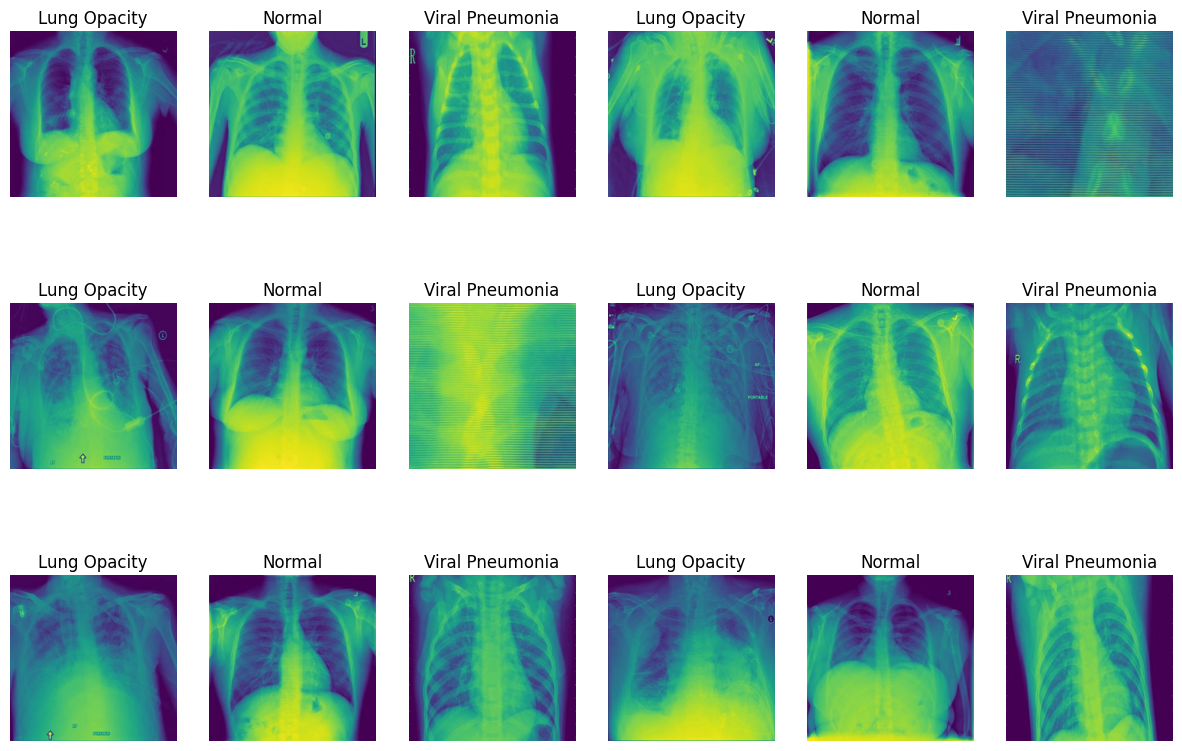

In [ ]:
import matplotlib.pyplot as plt

# Define the number of images to display from each class
num_images_per_class = 6

# Get class labels
class_labels = list(train_generator.class_indices.keys())

# Plot images from each class
plt.figure(figsize=(15, 10))
for label in class_labels:
  # Get indices of images belonging to the current class
  indices = train_df[train_df['labels'] == label].index

  # Randomly sample a subset of indices if there are more than the desired number of images per class
  indices = np.random.choice(indices, min(num_images_per_class, len(indices)), replace=False)

  # Plot images
  for i, idx in enumerate(indices):
    plt.subplot(len(class_labels), num_images_per_class, len(class_labels)*i + class_labels.index(label) + 1)
    plt.imshow(plt.imread(train_df.loc[idx, 'filepaths']))  # Load and plot the image
    plt.title(label)
    plt.axis('off')
plt.show()

# Model (InceptionV3)

In [ ]:
def build_InceptionV3_model():
  # Memanggil model dasar (base_model)
  base_model = InceptionV3(
    # Model ini sudah dilatih sebelumnya menggunakan jutaan gambar dari database ImageNet
    weights='imagenet',
    # Bagian klasifikasi asli (lapisan terakhir) dibuang.
    include_top=False,
    # Teknik untuk mengambil fitur paling menonjol dari hasil ekstraksi gambar
    pooling='max')

  x = base_model.output
  # Lapisan saraf dengan 256 neuron
  x = Dense(256, activation='relu')(x)
  # Ia akan mematikan 40% neuron secara acak selama latihan agar model lebih mandiri
  x = Dropout(0.4)(x)
  # Fungsi softmax mengubah output menjadi nilai probabilitas
  predictions = Dense(3, activation='softmax')(x)
  # Create the Keras Model object
  model = Model(inputs=base_model.input, outputs=predictions)

  return model

# Fungsi dipanggil untuk membuat objek model.
InceptionV3_model = build_InceptionV3_model()
#
InceptionV3_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        864 │ input_layer[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,216 │ activation[0][0]  │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │     18,432 │ activation_1[0][… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      5,120 │ max_pooling2d[0]… │
│                     │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 80)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │    138,240 │ activation_3[0][… │
│                     │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 192)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, None,      │          0 │ batch_normalizat

 Total params: 22,328,099 (85.17 MB)

 Trainable params: 22,293,667 (85.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

## Tuning Hyperparameter 1

In [ ]:
# Pengaturan Hyperparameter
# Satu epoch berarti model telah melihat dan mempelajari seluruh gambar di dataset pelatihan sebanyak satu kali
epochs = 10
# Jika terlalu besar, model akan ceroboh dan gagal konvergen; jika terlalu kecil, proses belajar akan sangat lama.
learning_rate = 0.001

# Kompilasi model
InceptionV3_model.compile(
  # Algoritma yang bertugas memperbarui bobot (pengetahuan) model agar kesalahannya semakin kecil.
  optimizer=Adamax(learning_rate=learning_rate),
  # Menghitung seberapa jauh prediksi model dari label asli yang benar
  loss='categorical_crossentropy',
  # Persentase jumlah tebakan yang benar dibandingkan total data.
  metrics=['accuracy'])

# Eksekusi Pelatihan Fit
history1 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=val_generator)

Epoch 1/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 110s 558ms/step - accuracy: 0.5440 - loss: 0.9217 - val_accuracy: 0.5797 - val_loss: 0.8355
Epoch 2/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 364ms/step - accuracy: 0.6180 - loss: 0.7510 - val_accuracy: 0.5605 - val_loss: 0.9008
Epoch 3/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 355ms/step - accuracy: 0.7512 - loss: 0.5972 - val_accuracy: 0.7255 - val_loss: 0.7046
Epoch 4/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 363ms/step - accuracy: 0.8117 - loss: 0.4889 - val_accuracy: 0.8330 - val_loss: 0.5372
Epoch 5/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 352ms/step - accuracy: 0.8343 - loss: 0.4280 - val_accuracy: 0.7985 - val_loss: 0.4822
Epoch 6/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.8627 - loss: 0.3851 - val_accuracy: 0.8522 - val_loss: 0.4427
Epoch 7/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 352ms/step - accuracy: 0.8787 - loss: 0.3293 - val_accuracy: 0.8733 - val_loss: 0.3923
Epoch 8/10
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.8890 - loss: 0.3007 - val_acc

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# Prediksi Model
start_time = time.time()
Y_pred = InceptionV3_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
# Hitung Akurasi
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.001
Epoch: 10
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.8582
Total Waktu Prediksi : 1.93 detik


In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                 precision    recall  f1-score   support

   Lung Opacity      0.774     0.911     0.837       169
         Normal      0.852     0.798     0.824       188
Viral Pneumonia      0.980     0.873     0.923       165

       accuracy                          0.858       522
      macro avg      0.869     0.861     0.861       522
   weighted avg      0.867     0.858     0.860       522




--- Confusion Matrix ---


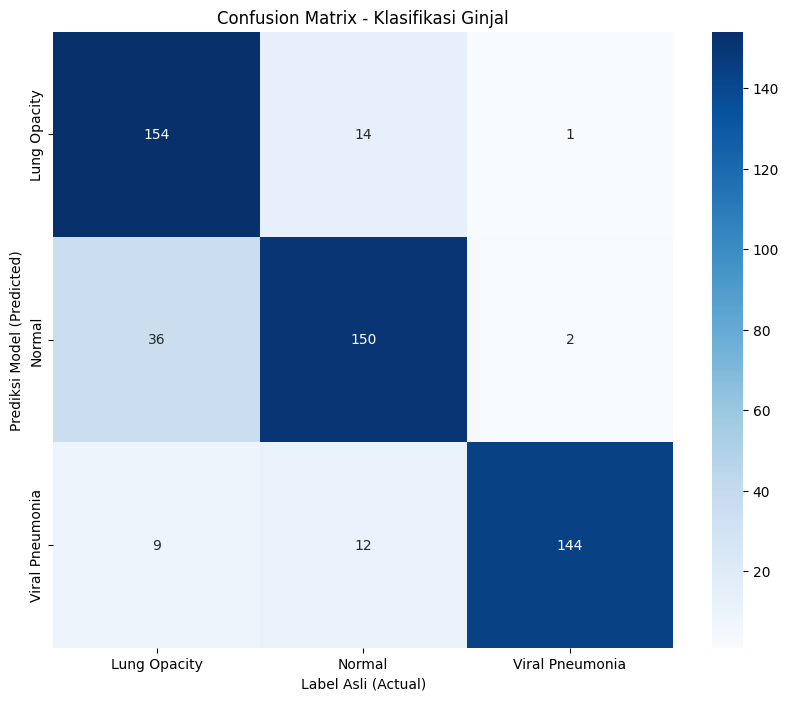

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

## Tuning Hyperparameter 2

In [ ]:
epochs = 20
learning_rate = 0.001

InceptionV3_model.compile(
  optimizer=Adamax(learning_rate=learning_rate),
  loss='categorical_crossentropy',
  metrics=['accuracy'])

history1 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=val_generator)

Epoch 1/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 105s 518ms/step - accuracy: 0.8775 - loss: 0.3488 - val_accuracy: 0.8772 - val_loss: 3.1192
Epoch 2/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 351ms/step - accuracy: 0.9231 - loss: 0.2266 - val_accuracy: 0.8964 - val_loss: 0.3229
Epoch 3/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 356ms/step - accuracy: 0.9416 - loss: 0.1742 - val_accuracy: 0.8426 - val_loss: 0.4423
Epoch 4/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 363ms/step - accuracy: 0.9437 - loss: 0.1562 - val_accuracy: 0.8887 - val_loss: 0.3226
Epoch 5/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 353ms/step - accuracy: 0.9613 - loss: 0.1245 - val_accuracy: 0.8964 - val_loss: 0.3725
Epoch 6/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.9708 - loss: 0.0907 - val_accuracy: 0.8791 - val_loss: 0.4154
Epoch 7/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 352ms/step - accuracy: 0.9671 - loss: 0.1054 - val_accuracy: 0.8848 - val_loss: 0.5083
Epoch 8/20
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 353ms/step - accuracy: 0.9823 - loss: 0.0686 - val_acc

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# Prediksi Model
start_time = time.time()
Y_pred = InceptionV3_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
# Hitung Akurasi
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 487ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.001
Epoch: 20
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.8966
Total Waktu Prediksi : 15.06 detik


In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                 precision    recall  f1-score   support

   Lung Opacity      0.876     0.876     0.876       169
         Normal      0.870     0.856     0.863       188
Viral Pneumonia      0.946     0.964     0.955       165

       accuracy                          0.897       522
      macro avg      0.897     0.899     0.898       522
   weighted avg      0.896     0.897     0.896       522




--- Confusion Matrix ---


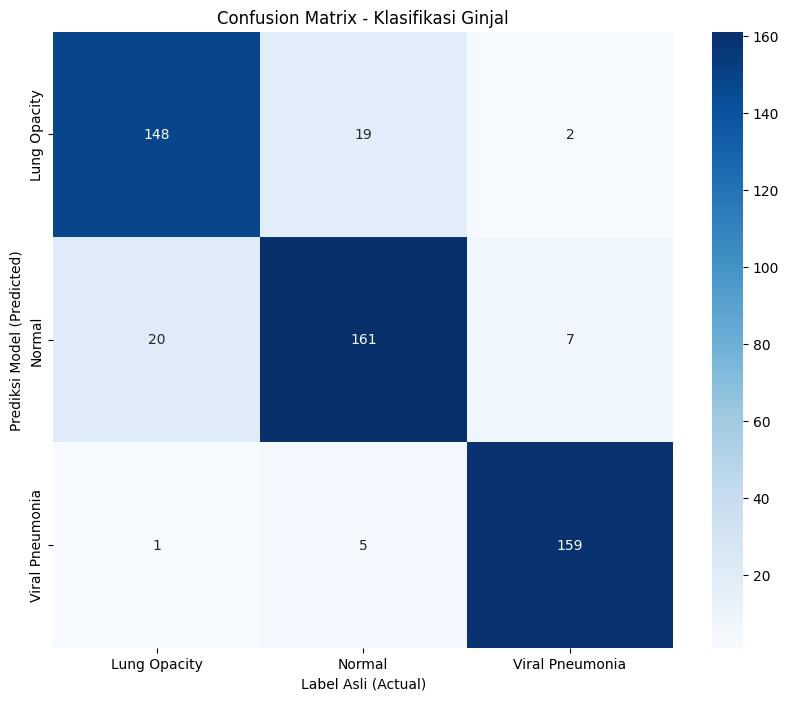

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

## Tuning Hyperparameter 3

In [ ]:
epochs = 30
learning_rate = 0.001

InceptionV3_model.compile(
  optimizer=Adamax(learning_rate=learning_rate),
  loss='categorical_crossentropy',
  metrics=['accuracy'])

history1 = InceptionV3_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=val_generator)

Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 106s 526ms/step - accuracy: 0.9412 - loss: 0.2052 - val_accuracy: 0.9040 - val_loss: 0.7889
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 349ms/step - accuracy: 0.9860 - loss: 0.0458 - val_accuracy: 0.9040 - val_loss: 0.4390
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 28s 362ms/step - accuracy: 0.9926 - loss: 0.0293 - val_accuracy: 0.8868 - val_loss: 0.4709
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.9955 - loss: 0.0190 - val_accuracy: 0.8944 - val_loss: 0.4017
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 352ms/step - accuracy: 0.9979 - loss: 0.0095 - val_accuracy: 0.9194 - val_loss: 0.4523
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 354ms/step - accuracy: 0.9992 - loss: 0.0048 - val_accuracy: 0.9194 - val_loss: 0.5091
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 353ms/step - accuracy: 1.0000 - loss: 6.9071e-04 - val_accuracy: 0.9251 - val_loss: 0.5449
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 27s 351ms/step - accuracy: 1.0000 - loss: 3.6971e-04 -

In [ ]:
# Reset generator agar prediksi dimulai dari awal dataset
test_generator.reset()

# Prediksi Model
start_time = time.time()
Y_pred = InceptionV3_model.predict(test_generator)
end_time = time.time()

# Waktu Inferensi
inference_time = end_time - start_time
# Prediksi Kelas
y_pred = np.argmax(Y_pred, axis=1)
# Label sebenarnya
y_true = test_generator.classes # Mengambil label asli sesuai urutan folder
# Hitung Akurasi
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"--- Hasil Evaluasi Data Test ---")
print(f"Akurasi Testing : {test_accuracy:.4f}")
print(f"Total Waktu Prediksi : {inference_time:.2f} detik")

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 518ms/step
Hyperparameter: 
Batch Size: 32
Learning Rate: 0.001
Epoch: 30
--- Hasil Evaluasi Data Test ---
Akurasi Testing : 0.9042
Total Waktu Prediksi : 14.79 detik


In [ ]:
# Menampilkan Classification Report
# Ini akan menunjukkan Precision, Recall, dan F1-Score untuk setiap jenis penyakit ginjal
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
# Menambahkan parameter digits=3 untuk menampilkan 3 angka di belakang koma
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
                 precision    recall  f1-score   support

   Lung Opacity      0.886     0.876     0.881       169
         Normal      0.877     0.872     0.875       188
Viral Pneumonia      0.952     0.970     0.961       165

       accuracy                          0.904       522
      macro avg      0.905     0.906     0.906       522
   weighted avg      0.904     0.904     0.904       522




--- Confusion Matrix ---


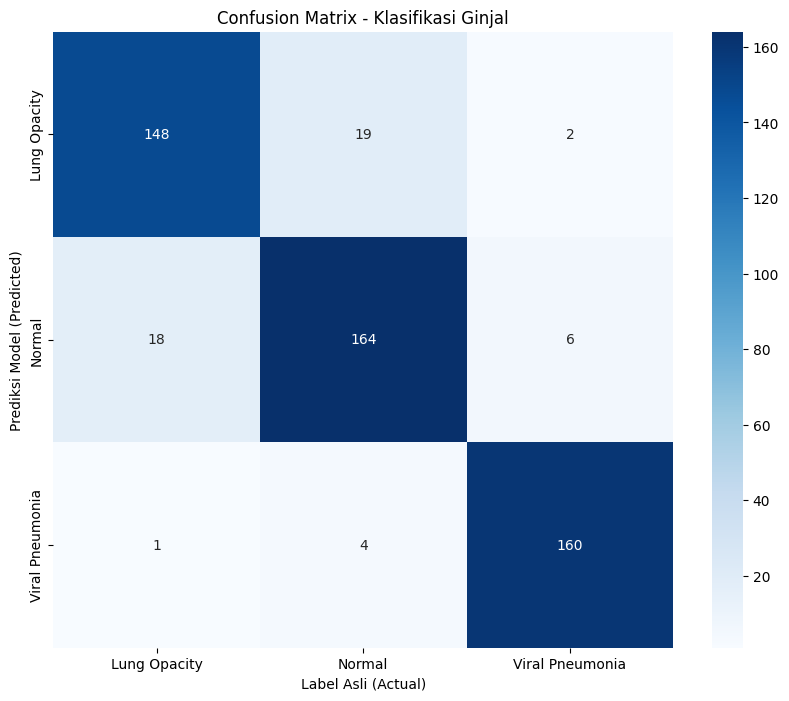

In [ ]:
# Membuat Confusion Matrix (Visual)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Klasifikasi Ginjal')
plt.xlabel('Label Asli (Actual)')
plt.ylabel('Prediksi Model (Predicted)')
plt.show()

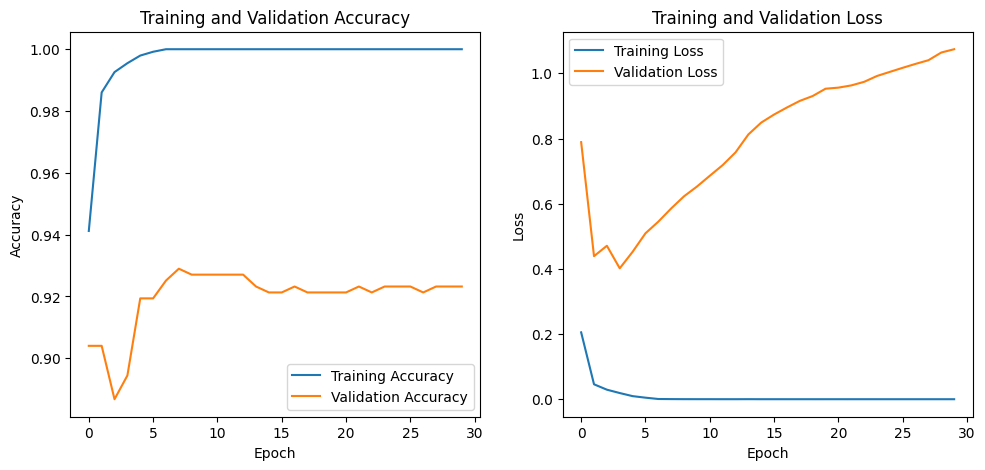

In [39]:
# Plot training and validation accuracy
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 3, 2)
plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Prediction on New Image

Saving viral_pneumonia.jpeg to viral_pneumonia (4).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)
/tmp/ipykernel_8240/3199803178.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


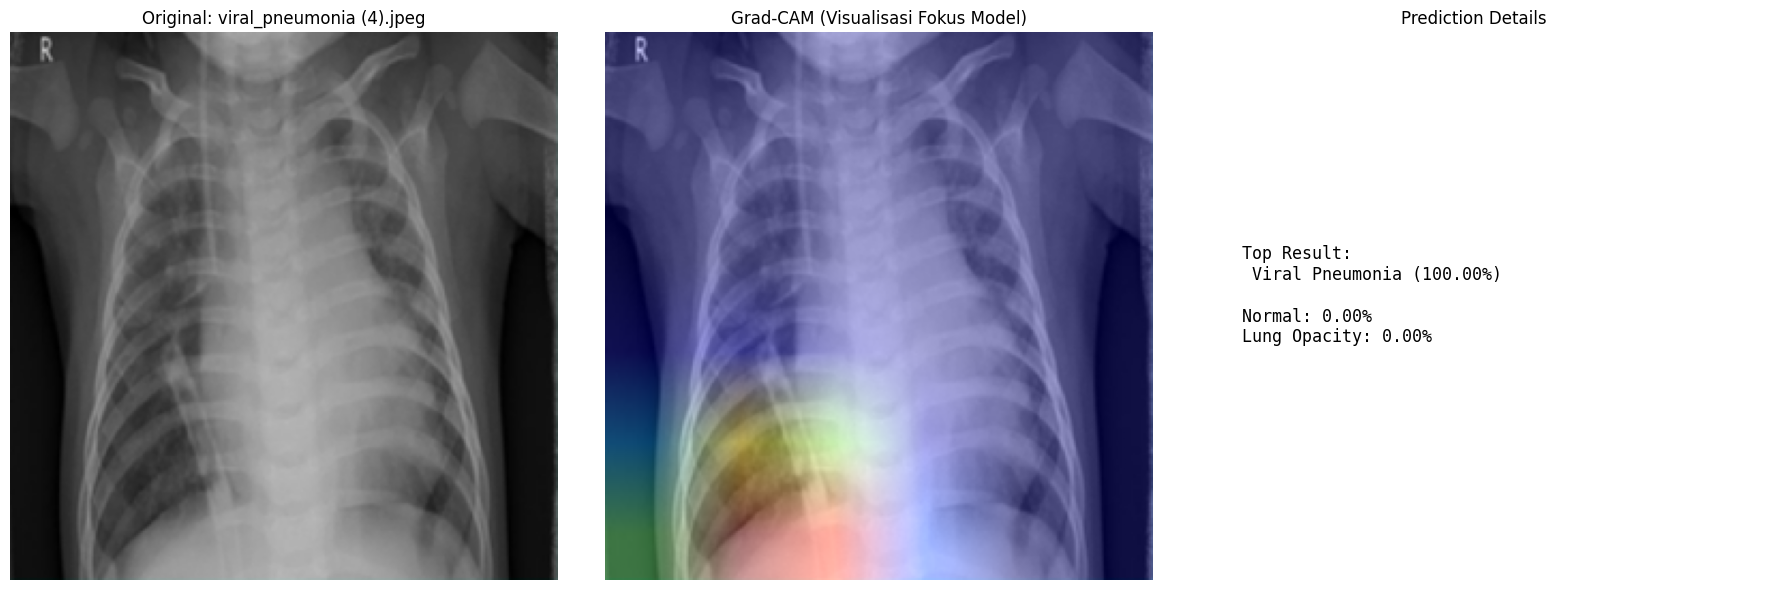

In [55]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
from google.colab import files

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
  # Model untuk memetakan input ke lapisan konvolusi terakhir
  grad_model = tf.keras.models.Model(
    [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
  )

  with tf.GradientTape() as tape:
    last_conv_layer_output, preds = grad_model(img_array)
    if pred_index is None:
      pred_index = tf.argmax(preds[0])
    class_channel = preds[:, pred_index]

  # Gradient dari class output terhadap feature map lapisan konvolusi terakhir
  grads = tape.gradient(class_channel, last_conv_layer_output)

  # Mean intensity dari gradient per saluran (channel)
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # Kalikan setiap saluran di feature map dengan "seberapa penting saluran itu"
  last_conv_layer_output = last_conv_layer_output[0]
  heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap)

  # Normalisasi heatmap antara 0 & 1 untuk visualisasi
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
  return heatmap.numpy()

def upload_predict_gradcam(model, class_labels):
  # InceptionV3 biasanya menggunakan 'mixed10' sebagai lapisan konvolusi terakhir
  last_conv_layer_name = "mixed10"
  uploaded = files.upload()

  for filename in uploaded.keys():
    # 1. Load & Preprocess
    img = image.load_img(filename, target_size=(256, 256))
    img_array = image.img_to_array(img)
    img_array_norm = np.expand_dims(img_array / 255.0, axis=0)

    # 2. Prediksi
    preds = model.predict(img_array_norm)[0]
    top_idx = np.argmax(preds)

    # 3. Hitung Grad-CAM Heatmap
    heatmap = make_gradcam_heatmap(img_array_norm, model, last_conv_layer_name, pred_index=top_idx)

    # 4. Gabungkan Heatmap dengan Gambar Asli
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.image.resize(jet_heatmap, (256, 256)).numpy()

    superimposed_img = jet_heatmap * 0.4 + (img_array / 255.0) # Opasitas 40% heatmap
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # 5. Teks Prediksi (Sesuai permintaan Anda)
    results = sorted(zip(class_labels, preds * 100), key=lambda x: x[1], reverse=True)
    display_text = f"Top Result:\n {results[0][0]} ({results[0][1]:.2f}%)\n\n"
    for name, prob in results[1:]:
        display_text += f"{name}: {prob:.2f}%\n"

    # 6. Visualisasi
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img)
    ax[0].set_title(f"Original: {filename}")
    ax[0].axis('off')

    ax[1].imshow(superimposed_img)
    ax[1].set_title("Grad-CAM (Visualisasi Fokus Model)")
    ax[1].axis('off')

    ax[2].text(0.1, 0.5, display_text, fontsize=12, family='monospace', verticalalignment='center')
    ax[2].set_title("Prediction Details")
    ax[2].axis('off')

    plt.tight_layout()
    plt.show()

# --- EKSEKUSI ---
labels = list(train_generator.class_indices.keys())
upload_predict_gradcam(InceptionV3_model, labels)

Saving lung_opacity.jpeg to lung_opacity (1).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


/tmp/ipykernel_8240/3199803178.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


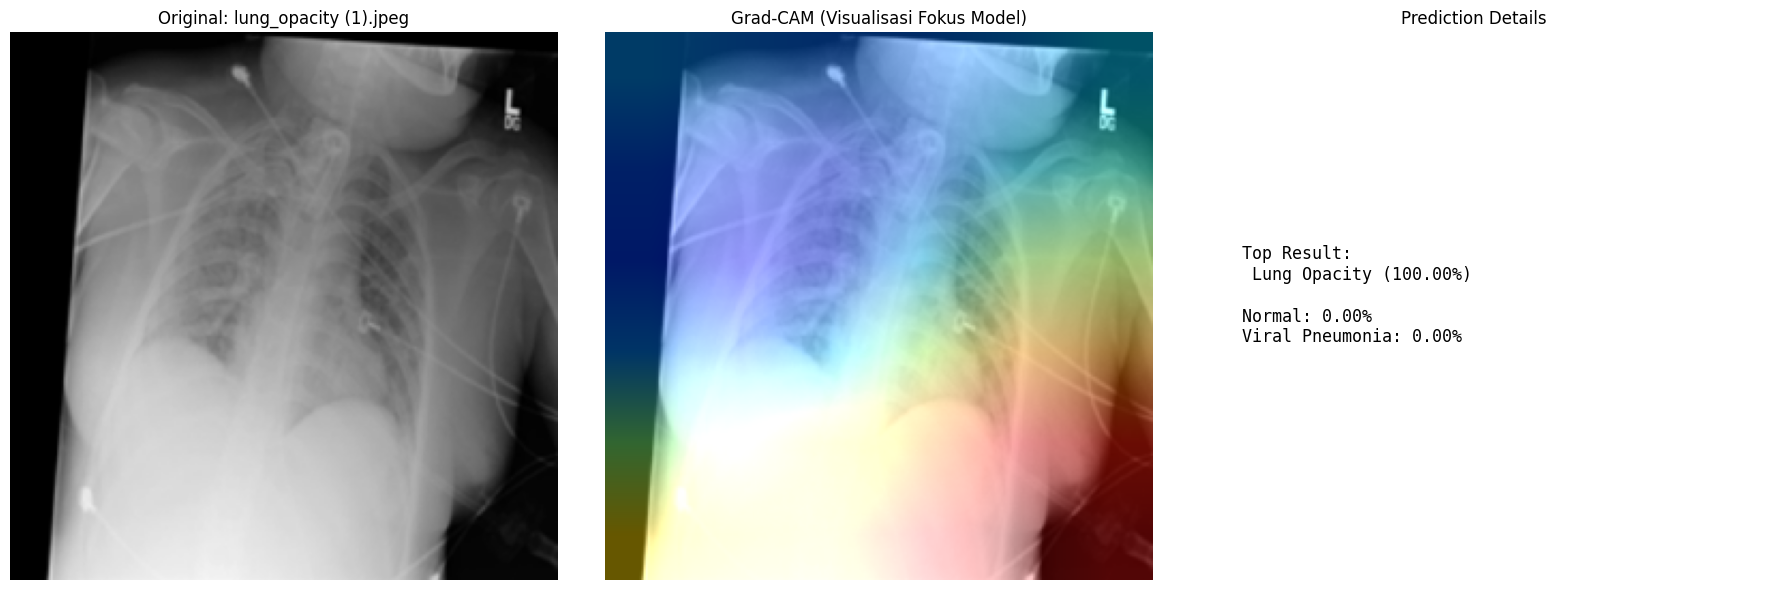

In [56]:
upload_predict_gradcam(InceptionV3_model, labels)